In [1]:
%env CUDA_VISIBLE_DEVICES=0
import torch
from torch import Tensor
import yaml
from models.vaectorgen import VAEctorGen
from models.vector_vae_nlayers import VectorVAEnLayers
from dataset import MNISTDataset
from PIL import Image
import matplotlib.pyplot as plt
import os
import yaml
from dataset import VQDataModule, GenericRasterizedSVGDataset, GenericRasterDataset
from models import VQ_SVG_Stage2, Vector_VQVAE
from tokenizer import VQTokenizer
from experiment import SVG_VQVAE_Stage2_Experiment
import torch
import random
import matplotlib.pyplot as plt
import numpy as np
import torchvision.utils as vutils
from PIL import Image
from torch import Tensor

from torchvision.utils import make_grid, save_image
torch.cuda.is_available()
from utils import calculate_global_positions, shapes_to_drawing, drawing_to_tensor
from svg_fixing import get_fixed_svg_drawing, get_fixed_svg_render
import pandas as pd
def map_wand_config(config):
    new_config = {}
    for k, v in config.items():
        if not "wandb" in k:
            new_config[k] = v["value"]
    return new_config

env: CUDA_VISIBLE_DEVICES=0


/home/mfeuerpfeil/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
df = pd.read_csv("/scratch2/moritz_data/raster_figr8/split.csv")
df.head()

In [ ]:
df_user = df[df["class"] == "user"].reset_index(drop=True)

In [ ]:
df_user.loc[df_user["split"] == "test", "split"] = "val"
df_user.loc[df_user["split"] == "held_back", "split"] = "test"

In [ ]:
df_user.to_csv("/scratch2/moritz_data/raster_figr8/split_user_only.csv", index=False)

In [ ]:
df[df["class"] == "star"].reset_index(drop=True).to_csv("/scratch2/moritz_data/figr8/stage2_final_star_only.csv", index=False)

In [ ]:
from utils import svg2paths2, raster, disvg
def svg_file_path_to_tensor(path, permuted = True, plot=False, stroke_width=0.5, filling:bool=False,image_size:int=224):
    paths, attributes, svg_attributes = svg2paths2(path)
    for i, attr in enumerate(attributes):
        attr["stroke_width"] = f"{stroke_width}"
        attr["fill"] = "black" if filling else "none"

    if "viewbox" in svg_attributes:
        viewbox = svg_attributes["viewbox"]
    else:
        viewbox = None
    return_tensor = raster(disvg(paths, attributes=attributes,paths2Drawing=True, viewbox=viewbox), out_h=image_size, out_w = image_size)
    return return_tensor

In [ ]:
plt.imshow(svg_file_path_to_tensor("/home/mfeuerpfeil/master/thesis/images/im2vec/star_fig8/samples/im2vec_sample_178.svg",stroke_width=0.4, image_size=480, filling=False).permute(1,2,0))

# Vector_VQVAE

## Load model and checkpoint

In [2]:
import yaml
from models import Vector_VQVAE
config_path = "/home/mfeuerpfeil/master/thesis/configs/SVG_VQVAE_Stage1_figr8.yaml"
with open(config_path, 'r') as file:
    try:
        config = yaml.safe_load(file)
    except yaml.YAMLError as exc:
        print(exc)

# adjust for inference
config['data_params']["max_shapes_per_svg"] = 200

device = "cuda" if torch.cuda.is_available() else "cpu"
model = Vector_VQVAE(**config['model_params']).to(device)

ckpt_path = "/scratch2/moritz_logs/SVG_VQVAE/Stage1/figr8_complex/checkpoints/last-v1.ckpt"
state_dict = torch.load(ckpt_path, map_location=device)["state_dict"]
model.load_state_dict({k.replace("model.", ""): v for k, v in state_dict.items()})
model=model.eval()
tokenizer = tokenizer = VQTokenizer(model, config["data_params"]["width"], 1, "bert-base-uncased", device = device)

## heatmap of positions

In [3]:
path = "/scratch2/moritz_data/figr8/tokenized/tokenized.npy"
tokenized = np.load(path, allow_pickle=True)

In [4]:
token_list = np.split(tokenized, np.where(tokenized==1)[0])[1:]

In [ ]:
lens = [len(x) for x in token_list]

In [ ]:
plt.hist(np.array(lens),bins=100)

In [5]:
all_stroke_tokens = tokenized[tokenized!=1][::2]
all_pos_tokens = tokenized[tokenized!=1][1::2]
all_stroke_tokens_tensor = torch.from_numpy(all_stroke_tokens.astype(np.int64))
all_pos_tokens_tensor = torch.from_numpy(all_pos_tokens.astype(np.int64))

In [ ]:
decoded_positions = tokenizer.decode_positions(all_pos_tokens_tensor)

In [ ]:
import matplotlib.colors as mcolors
def plot_heatmap(positions, size=(100, 100), save=None):
    """
    Plots a 100x100 heatmap for a tensor of positions.

    Parameters:
    - positions: A 2D numpy array or list of lists where each sub-list contains the x and y coordinates.
    - size: A tuple indicating the size of the heatmap grid. Default is (100, 100).
    """
    # Convert positions to a 2D histogram
    heatmap, _, _ = np.histogram2d(x=positions[:, 0], y=positions[:, 1], bins=size, range=[[0, size[0]], [0, size[1]]])

    # Create the plot
    fig, ax = plt.subplots(figsize=(8, 6))
    c = ax.pcolormesh(heatmap.T, cmap='plasma', norm=mcolors.PowerNorm(0.5))
    fig.colorbar(c, ax=ax)

    # Set titles and labels
    # ax.set_title('Heatmap of tokenized FIGR8 positions', fontsize=15)
    ax.set_xlabel('X position', fontsize=12)
    ax.set_ylabel('Y position', fontsize=12)

    # Invert y-axis to have the origin at the top left corner
    plt.gca().invert_yaxis()

    # Improve layout
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=300)

    # Show the plot
    plt.show()

plot_heatmap(decoded_positions.numpy(), size = (72,72), save="images/paper/heatmap_positions.png")

In [ ]:
tokenizer.max_num_pos_tokens

In [ ]:
encoder_params = sum(p.numel() for p in model.encoder.parameters()) / 1_000_000
decoder_params = sum(p.numel() for p in model.decoder.parameters()) / 1_000_000

print(f"Number of parameters in the encoder: {encoder_params:.2f} million")
print(f"Number of parameters in the decoder: {decoder_params:.2f} million")

total_params = sum(p.numel() for p in model.parameters()) / 1_000_000
print(f"Total number of parameters in the model: {total_params:.2f} million")

## prepare data

In [ ]:
from dataset import GlyphazznStage1Datamodule
dm = GlyphazznStage1Datamodule(**config['data_params'], test_batch_size=2)
dm.setup()
val_dl = dm.test_dataloader()
dataset = dm.test_dataset

## inference

In [ ]:
from tqdm import tqdm
all_losses = []
model = model.eval()
if True:
    with torch.no_grad():
        for batch in tqdm(val_dl, total=len(val_dl)):
            all_center_shapes, _, positions,_ = batch
            all_center_shapes = all_center_shapes.to(device)
            positions = positions.to(device)
            # out, logging_dict = model.forward(all_center_shapes)
            # reconstructions=out[0][:,:3,:,:]
            # loss_dict = model.loss_function(
            #         reconstructions=reconstructions,
            #         gt_images=all_center_shapes,
            #         vq_loss=torch.tensor(0.0).to(device),
            #         points = out[2]
            # )
            # # reconstructed_drawing, rasterized_reconstructions = model.reconstruct(all_center_shapes, positions, dm.individual_max_length +2, dm.stroke_width)
            # all_losses.append(loss_dict["loss"])
            break

In [ ]:
all_center_shapes.shape

In [ ]:
dataset.individual_max_length

In [ ]:
# Get the ground truth SVG drawing
idx = 0
gt = dataset._get_full_svg_drawing(idx, width=w, as_tensor=False)

# Reconstruct the SVG drawing
patches, labels, positions, _ = dataset._get_full_item(idx)
patches = patches.to(device)
positions = positions.to(device)
recons_drawing, _ = model.reconstruct(patches, positions, dataset.individual_max_length +2, dataset.stroke_width, rendered_w=w)

In [ ]:
recons_drawing

In [ ]:
gt

In [ ]:
from typing import List
from torchvision import transforms
from PIL import Image
import wandb
import numpy as np
import torch
from torch import Tensor
import os
from torchvision.utils import make_grid
from torchvision.transforms import Resize
from svgwrite import Drawing
from svgpathtools import disvg, CubicBezier, Line
import cairosvg
from PIL import Image
from io import BytesIO
from torchvision.transforms import ToTensor
import re
import matplotlib.colors as mcolors
from utils import stroke_to_path
def shapes_to_drawing2(shapes:Tensor, stroke_width:float, w=128, num_strokes_to_paint:int = 0) -> Drawing:
    """
    expects shapes to be in shape (n, 4, 2)
    """
    all_shapes = []
    for shape in shapes:
        all_shapes.append(stroke_to_path(shape))
    if num_strokes_to_paint > len(all_shapes):
        num_strokes_to_paint = len(all_shapes)
    colors = ["red"] * num_strokes_to_paint + ["black"] * (len(all_shapes) - num_strokes_to_paint)
    drawing = disvg(all_shapes, stroke_widths=[stroke_width]*len(all_shapes), colors=colors, paths2Drawing=True, viewbox=f"0 0 72 72", dimensions=(w, w))  # I think the 72 comes from the simplified svg files
    return drawing
w=72
shapes_to_drawing2(out[2][0].cpu()*w, stroke_width=3, w=w)

In [ ]:
out[2][0]

## visualization

In [ ]:
import torchvision.utils as vutils
from thesis.utils import add_points_to_image
def visualize_comparison(reconstructions, gt, save_path=None):
    # Create grids of images
    reconstructions_grid = vutils.make_grid(reconstructions, nrow=16, padding=2, normalize=True)
    gt_grid = vutils.make_grid(gt, nrow=16, padding=2, normalize=True)

    # Create a side-by-side comparison
    comparison = torch.cat((gt_grid, reconstructions_grid), dim=2)

    # Convert the comparison to a numpy array
    comparison_np = comparison.permute(1, 2, 0).cpu().numpy()

    # Display the comparison
    plt.imshow(comparison_np)
    plt.axis('off')
    if save_path is not None:
        plt.savefig(save_path, dpi=600)
    plt.show()
    
sample = 32
visualize_comparison(add_points_to_image(out[2][:sample], out[0][:sample,:3,:,:], out[0].shape[-1]), all_center_shapes[:sample], save_path="test.png")

In [ ]:
import random
from thesis.utils import fig2img
import matplotlib.pyplot as plt
from thesis.dataset import GlyphazznStage1Dataset

random_idx = random.randint(0, len(dm.val_dataset))
dataset = dm.val_dataset
w = 480

def get_side_by_side_reconstruction(model:Vector_VQVAE, dataset:GlyphazznStage1Dataset, idx, device, w=480):
    # Get the ground truth SVG drawing
    gt = dataset._get_full_svg_drawing(idx, width=w, as_tensor=True)

    # Reconstruct the SVG drawing
    patches, labels, positions, _ = dataset._get_full_item(idx)
    patches = patches.to(device)
    positions = positions.to(device)
    _, recons_rastered_drawing = model.reconstruct(patches, positions, dataset.individual_max_length +2, dataset.stroke_width, rendered_w=w)
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    # Plot reconstructed drawing
    axes[1].imshow(recons_rastered_drawing.permute(1, 2, 0))
    axes[1].set_title('Reconstructed SVG')

    # Plot ground truth drawing
    axes[0].imshow(gt.permute(1, 2, 0))
    axes[0].set_title('Ground Truth SVG')
    for ax in axes:
        ax.axis('off')
     
    fig.tight_layout()

    return fig2img(fig)

img = get_side_by_side_reconstruction(model, dataset, random_idx, device, w)
img.show()

In [ ]:
img

## visualize codebook usage

In [6]:
from utils import shapes_to_drawing
from utils import *
df = pd.read_csv("/scratch2/moritz_data/figr8/tokenized/stroke_token_counts.csv")
df.head()

,stroke_token,counts,count_percent
0,3648,8973047,18.76
1,718,5865919,12.26
2,543,1224368,2.56
3,738,828126,1.73
4,1720,553820,1.16


In [7]:
# get classes with most horizontal strokes

df2 = pd.read_csv("/scratch2/moritz_data/figr8/tokenized/split.csv")

top_horizontal_token_id = 3648

horizontal_token_lengths = [(x==top_horizontal_token_id).sum() for x in token_list]
horizontal_token_lengths = np.array(horizontal_token_lengths)
sorted_idxs = np.argsort(horizontal_token_lengths)[::-1]

In [28]:
df2.head()

,index_in_numpy_array,class,split
0,0,bottle,train
1,1,bottle,train
2,2,bottle,train
3,3,bottle,train
4,4,bottle,train


In [42]:
horizontal_strokes_dicts = []
for idx in tqdm(sorted_idxs):
    c = df2[df2["index_in_numpy_array"] == idx]["class"].values[0]
    num_stroke = horizontal_token_lengths[idx]
    horizontal_strokes_dicts.append({"class":c, "num_horizontal_stroke":num_stroke,"pct_horizontal_strokes":num_stroke/len(token_list[idx][1:])*100})

100%|██████████| 300100/300100 [01:11<00:00, 4171.71it/s]


In [43]:
horizontal_df = pd.DataFrame(horizontal_strokes_dicts)
horizontal_df.head()

,class,num_horizontal_stroke,pct_horizontal_strokes
0,sun,477,46.582031
1,book,472,46.093750
2,book,468,45.703125
3,book,466,45.507812
4,book,464,45.312500


In [44]:
horizontal_df.groupby("class").mean().sort_values("pct_horizontal_strokes", ascending=False)

,num_horizontal_stroke,pct_horizontal_strokes
class,,
menu,71.233918,26.013863
credit card,86.514028,24.260664
laptop,95.483959,24.049222
monitor,86.257700,23.821292
comnputer,85.749147,21.310071
...,...,...
heart,2.713466,0.838726
flower,2.807256,0.741920
compas,2.368363,0.711480


In [31]:
dict(zip(classes, num_strokes))

{'sun': 477,
 'book': 391,
 'comnputer': 447,
 'user': 446,
 'envelop': 411,
 'caledar': 415,
 'star': 407}

In [ ]:
model.codebook_size

In [8]:
from tqdm import tqdm

def get_positions_from_code_index(token, model, device):
    result, _ = model.decode_from_indices(torch.tensor(token).to(device).unsqueeze(0))
    _, _, stroke_positions, _ = result
    if stroke_positions.shape[1] == 1:
        stroke_positions = stroke_positions.squeeze(1)
    return stroke_positions

def get_shape_reduction(tokens, counts, model, device, reduction_type:str, stroke_width=0.5, w=224):
    all_strokes = []
    total_weight = 0
    
    for i, token in tqdm(enumerate(tokens),total=len(tokens)):
        if counts[i] == 0:
            continue
        stroke_positions = get_positions_from_code_index(token, model, device)
        
        rasterized_stroke_drawing = shapes_to_drawing(stroke_positions.cpu(), stroke_width=stroke_width, w=w)
        rasterized_stroke = drawing_to_tensor(rasterized_stroke_drawing)
        if reduction_type == "min":
            all_strokes.append(rasterized_stroke)
            continue
        else:
            weighted_stroke = rasterized_stroke.cpu() * counts[i]
            all_strokes.append(weighted_stroke)
            total_weight += counts[i]
    
    if reduction_type == "mean":
        weighted_sum = torch.stack(all_strokes).sum(dim=0)  # Sum the weighted tensors
        weighted_average = weighted_sum / total_weight  # Divide by the total weight
        
        return weighted_average
    elif reduction_type == "min":
        return torch.stack(all_strokes).min(dim=0)[0]
    elif reduction_type == "none":
        return torch.stack(all_strokes)
    else:
        raise ValueError("reduction_type must be either 'mean' or 'min'.")

def save_plot(img, path):
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    if img.shape[0] == 3:
        img = img.permute(1,2,0)
    ax.imshow(img)
    ax.axis('off')
    fig.savefig(path, dpi=300)

w=480
sw=0.2
# mean_strokes = get_shape_reduction(df.stroke_token.values, 
#                             df["counts"].values,
#                             model,
#                             device,
#                             reduction_type="mean",
#                             stroke_width=sw,
#                             w=w)
# mean_strokes_without_top_ten = get_shape_reduction(df.stroke_token.values[10:], 
#                             df["counts"].values[10:],
#                             model,
#                             device,
#                             reduction_type="mean",
#                             stroke_width=sw,
#                             w=w)
# mean_strokes_without_top_two = get_shape_reduction(df.stroke_token.values[2:], 
#                             df["counts"].values[2:],
#                             model,
#                             device,
#                             reduction_type="mean",
#                             stroke_width=sw,
#                             w=w)
# min_strokes = get_shape_reduction(df.stroke_token.values, 
#                             df["counts"].values,
#                             model,
#                             device,
#                             reduction_type="min",
#                             stroke_width=sw,
#                             w=w)
# names = ["mean_strokes", "mean_strokes_without_top_ten", "mean_strokes_without_top_two", "min_strokes"]
# figr_8_imgs = [mean_strokes, mean_strokes_without_top_ten, mean_strokes_without_top_two, min_strokes]
# for i,img in enumerate(figr_8_imgs):
#     torch.save(img, f"images/paper/codebook/pt/figr8_{names[i]}.pt")
#     fig, ax = plt.subplots(1, 1, figsize=(10, 10))
#     ax.imshow(img.permute(1,2,0))
#     ax.axis('off')
#     fig.savefig(f"images/paper/codebook/figr8_{names[i]}.png", dpi=300)

# codebook_min_strokes = get_shape_reduction(df.stroke_token.values, 
#                             df["counts"].values * 0 + 1,
#                             model,
#                             device,
#                             reduction_type="min",
#                             stroke_width=sw,
#                             w=w)
# codebook_mean_strokes = get_shape_reduction(df.stroke_token.values, 
#                             df["counts"].values * 0 + 1,
#                             model,
#                             device,
#                             reduction_type="mean",
#                             stroke_width=sw,
#                             w=w)

# torch.save(codebook_min_strokes, f"images/paper/codebook/pt/codebook_min_strokes.pt")
# torch.save(codebook_mean_strokes, f"images/paper/codebook/pt/codebook_mean_strokes.pt")
# names = ["codebook_min_strokes", "codebook_mean_strokes"]
# for i, x in enumerate([codebook_min_strokes, codebook_mean_strokes]):
#     fig, ax = plt.subplots(1, 1, figsize=(10, 10))
#     ax.imshow(x.permute(1,2,0))
#     ax.axis('off')
#     fig.savefig(f"images/paper/codebook/{names[i]}.png", dpi=300)

In [ ]:
codebook_used_strokes = get_shape_reduction(df[df["counts"]>0].stroke_token.values, 
                            df[df["counts"]>0]["counts"].values * 0 + 1,
                            model,
                            device,
                            reduction_type="min",
                            stroke_width=sw,
                            w=w)

codebook_unused_strokes = get_shape_reduction(df[df["counts"]==0].stroke_token.values, 
                            df[df["counts"]==0]["counts"].values * 0 + 1,
                            model,
                            device,
                            reduction_type="min",
                            stroke_width=sw,
                            w=w)

In [ ]:
save_plot(mean_strokes, "images/paper/codebook/figr8_mean_strokes.png")
save_plot(mean_strokes_without_top_ten, "images/paper/codebook/figr8_mean_strokes_without_top_ten.png")
save_plot(mean_strokes_without_top_two, "images/paper/codebook/figr8_mean_strokes_without_top_two.png")
save_plot(min_strokes, "images/paper/codebook/figr8_min_strokes.png")
save_plot(codebook_min_strokes, "images/paper/codebook/codebook_min_strokes.png")
save_plot(codebook_mean_strokes, "images/paper/codebook/codebook_mean_strokes.png")
save_plot(codebook_used_strokes, "images/paper/codebook/codebook_used_strokes.png")
save_plot(codebook_unused_strokes, "images/paper/codebook/codebook_unused_strokes.png")

In [10]:
sz = 10
codebook_used_strokes_sample = get_shape_reduction(df[df["counts"]>0].sample(sz).stroke_token.values, 
                            df[df["counts"]>0].sample(20)["counts"].values * 0 + 1,
                            model,
                            device,
                            reduction_type="none",
                            stroke_width=0.3,
                            w=w)

100%|██████████| 10/10 [00:00<00:00, 11.62it/s]


In [ ]:
fig, axes = plt.subplots(1, sz, figsize=(sz*5, 5))
for i, ax in enumerate(axes):
    ax.imshow(codebook_used_strokes_sample[i].permute(1,2,0))
    ax.axis('off')

In [11]:
for i in range(25):
    sample = df[df["counts"]>0].sample(1)
    positions = get_poisitons_from_code_index(sample.stroke_token.values[0], model, device)
    drawing = shapes_to_drawing(positions.cpu()*72, stroke_width=0.3, w=w)
    drawing.saveas(f"images/svgs/used_stroke_{sample.index.values[0]}.svg")

    sample = df[df["counts"]==0].sample(1)
    positions = get_poisitons_from_code_index(sample.stroke_token.values[0], model, device)
    drawing = shapes_to_drawing(positions.cpu()*72, stroke_width=0.3, w=w)
    drawing.saveas(f"images/svgs/unused_stroke_{sample.index.values[0]}.svg")

In [ ]:
stroke_to_path(positions[0]),positions[0]

In [45]:
128**2

16384

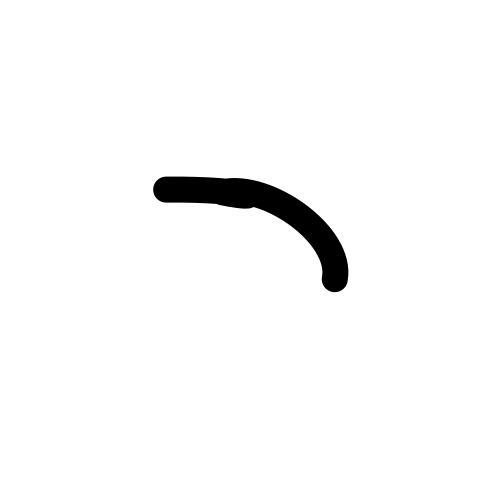

In [44]:
def shapes_to_drawing(shapes:Tensor, stroke_width:float|List, w=128, num_strokes_to_paint:int = 0, linecap="round", linejoin="round") -> Drawing:
    """
    expects shapes to be in shape (n, 1+3*num_segments, 2)
    """
    assert linecap in ["round", "butt", "square"], "linecap must be either 'round', 'butt' or 'square'."
    assert linejoin in ["round", "bevel", "miter"], "linejoin must be either 'round', 'bevel' or 'miter'."

    base_attribute = {
        "fill": "none",
        "fill-opacity": "1.0",
        "filling": "0",
        "stroke":"black",
        "stroke-width":"1",
        "stroke-linecap":linecap,
        "stroke-linejoin" : linejoin

    }
    if shapes.mean() < 2.0:
        shapes = shapes * 72
    assert shapes.mean() > 1.0 and shapes.mean() < 72.0, "shapes should be already scaled in range 0. - 72."
    all_shapes = []
    for shape in shapes:
        all_shapes.append(stroke_to_path(shape))
    if num_strokes_to_paint > len(all_shapes):
        num_strokes_to_paint = len(all_shapes)
    colors = ["red"] * num_strokes_to_paint + ["black"] * (len(all_shapes) - num_strokes_to_paint)
    if isinstance(stroke_width, float):
        stroke_widths = [stroke_width] * len(all_shapes)
    elif isinstance(stroke_width, list):
        stroke_widths = stroke_width
    all_attributes = []
    for i, shape in enumerate(all_shapes):
        attributes = base_attribute.copy()
        attributes["stroke-width"] = f"{stroke_widths[i]}"
        attributes["stroke"] = colors[i]
        all_attributes.append(attributes)
    drawing = disvg(all_shapes, attributes=all_attributes, paths2Drawing=True, viewbox=f"0 0 72 72", dimensions=(w, w))  # I think the 72 comes from the simplified svg files
    return drawing


sample = df[df["counts"]>0].sample(1)
positions = get_positions_from_code_index(sample.stroke_token.values[0], model, device)
drawing = shapes_to_drawing2(positions.cpu()*72, stroke_width=3.9, w=w)
drawing

In [ ]:
sz = 5
codebook_unused_strokes_sample = get_shape_reduction(df[df["counts"]==0].sample(sz).stroke_token.values, 
                            df[df["counts"]==0].sample(20)["counts"].values * 0 + 1,
                            model,
                            device,
                            reduction_type="none",
                            stroke_width=0.3,
                            w=w)
# plt.imshow(codebook_unused_strokes_sample.permute(1,2,0))
fig, axes = plt.subplots(1, sz, figsize=(sz*5, 5))
for i, ax in enumerate(axes):
    ax.imshow(codebook_unused_strokes_sample[i].permute(1,2,0))
    ax.axis('off')

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def plot_tensor_images(tensor):
    """
    Plots each image in the tensor with a separate color.
    Args:
    - tensor: A torch.Size([n, 1, 480, 480]) tensor containing the images.
    """
    n = tensor.shape[0]  # Number of images
    fig, axes = plt.subplots(1, n, figsize=(15, 60))  # Adjust figure size as needed
    cmap_list = ['viridis', 'plasma', 'inferno', 'magma', 'cividis']  # List of colormaps

    if n == 1:  # If there's only one image, axes is not a list
        axes = [axes]

    for i, ax in enumerate(axes):
        img = tensor[i].squeeze().numpy()  # Convert to numpy array and remove channel dimension
        cmap = cmap_list[i % len(cmap_list)]  # Cycle through the colormap list
        ax.imshow(img, cmap=cmap)
        ax.axis('off')  # Hide axes for cleaner look
    plt.tight_layout()
    plt.show()

# Example usage:
# Assuming `images` is your tensor of shape torch.Size([n, 1, 480, 480])
plot_tensor_images(codebook_unused_strokes_sample[:,0,:,:])


In [ ]:
plt.imshow(codebook_used_strokes.permute(1,2,0)) # I would add interpolation='none'
plt.axis('off')

In [ ]:
plt.imshow(min_strokes.permute(1,2,0)) # I would add interpolation='none'
plt.axis('off')

In [ ]:
plt.imshow(codebook_unused_strokes.permute(1,2,0)) # I would add interpolation='none'
plt.axis('off')

In [ ]:
plt.imshow(codebook_min_strokes[0], cmap='gray') # I would add interpolation='none'
plt.imshow(min_strokes[0], cmap='Blues', alpha=0.5*(min_strokes[0]<1)) # interpolation='none'
plt.axis('off')
plt.savefig("images/paper/codebook/min_strokes_comparison.png", dpi=300)

In [ ]:
fig,ax = plt.subplots(1,1, figsize=(10,10))
ax.imshow(torch.stack([codebook_min_strokes[0],torch.ones_like(codebook_min_strokes[0]),min_strokes[0]]).permute(1,2,0))
# ax.imshow(torch.stack([torch.ones_like(codebook_min_strokes[0]),min_strokes[0],torch.ones_like(codebook_min_strokes[0])]).permute(1,2,0))

In [ ]:
copy = mean_strokes_without_top_two.clone()
copy[copy < 0.99] = copy[copy < 0.99]/1.1

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(copy.permute(1,2,0))
ax.axis('off')

In [ ]:
model = model.eval()
top_ten_strokes = df.stroke_token[:10].values
with torch.no_grad():
    idxs = torch.from_numpy(top_ten_strokes).to(device)
    result, logging_dict = model.decode_from_indices(idxs)
    # result = result
    output, scenes, all_points, all_widths = result
    if all_points.shape[1] == 1:
        all_points = all_points.squeeze(1)
grid_w = int(np.ceil(np.sqrt(output.shape[0])))
grid_w = len(output)

In [ ]:

def shapes_to_drawing2(shapes, stroke_width, w=128, num_strokes_to_paint = 0):
    """
    expects shapes to be in shape (n, 1+3*num_segments, 2)
    """
    if shapes.mean() < 2.0:
        shapes = shapes * 72
    assert shapes.mean() > 1.0 and shapes.mean() < 72.0, "shapes should be already scaled in range 0. - 72."
    all_shapes = []
    for shape in shapes:
        all_shapes.append(stroke_to_path(shape))
    if num_strokes_to_paint > len(all_shapes):
        num_strokes_to_paint = len(all_shapes)
    colors = ["red"] * num_strokes_to_paint + ["black"] * (len(all_shapes) - num_strokes_to_paint)
    if isinstance(stroke_width, float):
        stroke_widths = [stroke_width] * len(all_shapes)
    elif isinstance(stroke_width, list):
        stroke_widths = stroke_width
    drawing = disvg(all_shapes, stroke_widths=stroke_widths, colors=colors, paths2Drawing=True, viewbox=f"0 0 72 72", dimensions=(w, w))  # I think the 72 comes from the simplified svg files
    return drawing

top_ten_drawings = []
for i, stroke in enumerate(all_points):
    # print(stroke*72)
    ströke = (stroke*72).unsqueeze(0)
    top_ten_drawings.append(shapes_to_drawing2(ströke, stroke_width=3., w=480))

top_ten_drawings[4]

In [ ]:
unique_strokes = df.stroke_token.unique()
drawing_dict = {}
for stroke in unique_strokes:
    idxs = torch.tensor([stroke]).to(device)
    result, logging_dict = model.decode_from_indices(idxs)
    output, scenes, all_points, all_widths = result
    if all_points.shape[1] == 1:
        all_points = all_points.squeeze(1)
    drawing_dict[stroke] = shapes_to_drawing(all_points, stroke_width=3., w=1280)

In [ ]:
model.codebook_size

In [ ]:
(df["counts"] == 0).sum() / 4375 * df.shape[0]

In [ ]:
8*5*5*5

In [ ]:
found25=False
found50=False
found75=False
found99=False
for i in range(len(df)):
    if df["count_percent"][:i].sum() > 25 and not found25:
        print(i,25)
        found25=True
    if df["count_percent"][:i].sum() > 50 and not found50:
        print(i,50)
        found50=True
    if df["count_percent"][:i].sum() > 75 and not found75:
        print(i,75)
        found75=True
    if df["count_percent"][:i].sum() > 99 and not found99:
        print(i,99)
        found99=True
    

In [ ]:
for i,drawing in enumerate(top_ten_drawings):
    drawing.saveas(f"images/paper/top_strokes/{i}_{top_ten_strokes[i]}.svg")

In [ ]:
all_points_to_mark = []
for p in all_points[0][::3]:
    all_points_to_mark.append(torch.stack([torch.tensor([0.0,0.0])]+([p.cpu()]*6)))

In [ ]:
all_points_to_mark[0].shape

In [ ]:
strokes_with_markings = torch.stack([all_points[0].cpu()]+all_points_to_mark)

In [ ]:
shapes_to_drawing2(strokes_with_markings, stroke_width=3., w=480, num_strokes_to_paint=1)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(25, 25))
ax.imshow(make_grid(output, nrow=grid_w).permute(1,2,0).cpu())
ax.axis("off")
# fig.savefig("all_strokes_codes_figr8.png", dpi=600)

# Stage 2

In [ ]:
# %env CUDA_VISIBLE_DEVICES=0
import os
import yaml
from dataset import VQDataModule
from models import VQ_SVG_Stage2, Vector_VQVAE
from tokenizer import VQTokenizer
from experiment import SVG_VQVAE_Stage2_Experiment
import torch
import random
import matplotlib.pyplot as plt
import numpy as np
import torchvision.utils as vutils
from PIL import Image
from torch import Tensor

from torchvision.utils import make_grid, save_image
torch.cuda.is_available()
from utils import calculate_global_positions, shapes_to_drawing, drawing_to_tensor
from svg_fixing import get_fixed_svg_drawing, get_fixed_svg_render
def map_wand_config(config):
    new_config = {}
    for k, v in config.items():
        if not "wandb" in k:
            new_config[k] = v["value"]
    return new_config

## Load everything

In [ ]:
CONFIG_PATH = "/scratch2/moritz_logs/SVG_VQVAE/Stage2/filtered_fonts_full_single_code/wandb/run-20240226_191349-ro48a2jp/files/config.yaml"
CKPT_PATH = "/scratch2/moritz_logs/SVG_VQVAE/Stage2/filtered_fonts_full_single_code/checkpoints/last-v1.ckpt"
DATASET = "fonts"

CONFIG_PATH = "/home/mfeuerpfeil/master/thesis/configs/figr8_stage2_marco.yaml"
CKPT_PATH = "/scratch2/gesùbambino/checkpoint_stage2_figr8/last-v2.ckpt"
DATASET = "figr8"

device = "cuda" if torch.cuda.is_available() else "cpu"

with open(CONFIG_PATH, 'r') as file:
    try:
        config = yaml.safe_load(file)
    except yaml.YAMLError as exc:
        print(exc)

# wandb configs need mapping
if "wandb_version" in config.keys():
    config = map_wand_config(config)


config["data_params"]["dataset"] = DATASET

vq_model = Vector_VQVAE(**config['stage1_params'], device = device)
state_dict = torch.load(config['stage1_params']["checkpoint_path"], map_location=device)["state_dict"]
try:
    vq_model.load_state_dict(state_dict)
except:
    vq_model.load_state_dict({k.replace("model.", ""): v for k, v in state_dict.items()})
vq_model = vq_model.eval()
tokenizer = VQTokenizer(vq_model, config["data_params"]["width"], 1, "bert-base-uncased", device = device)
model = VQ_SVG_Stage2(tokenizer, **config['model_params'], device = device)
state_dict = torch.load(CKPT_PATH, map_location=device)["state_dict"]
import re
try:
    model.load_state_dict(state_dict)
except:
    new_dict = state_dict
    # new_dict = {k.replace("transformer.model.", "model.transformer.model."): v for k, v in new_dict.items()}
    # new_dict = {k.replace("text_embedder.", "model.text_embedder."): v for k, v in new_dict.items()}
    new_dict = {k.replace("model.transformer.model.","transformer.model."): v for k, v in new_dict.items()}
    new_dict = {k.replace("model.text_embedder.","text_embedder."): v for k, v in new_dict.items()}
    new_dict = {k.replace("model.pos_emb.","pos_emb."): v for k, v in new_dict.items()}
    new_dict = {k.replace("model.vq_embedding.","vq_embedding."): v for k, v in new_dict.items()}
    new_dict = {k.replace("model.mapping_layer.","mapping_layer."): v for k, v in new_dict.items()}
    new_dict = {k.replace("model.final_linear.","final_linear."): v for k, v in new_dict.items()}
    # new_dict = {k.replace("tokenizer.vq_model", "tokenizer.vq_model.encoder"): v for k, v in new_dict.items()}
    # new_dict = {k.replace("tokenizer.vq_decoder", "tokenizer.vq_model.decoder"): v for k, v in new_dict.items()}
    # new_dict = {k.replace("model.", "",1): v for k, v in state_dict.items()}
    pattern = r"(\.ff\.2\.)(weight|bias)"
    replacement = r".ff.3.\2"
    new_dict = {re.sub(pattern,replacement,k): v for k, v in new_dict.items()}
    model.load_state_dict(new_dict)

model = model.eval().to(device)
text_only_tokenizer = VQTokenizer(None, config["data_params"]["width"], 1, "bert-base-uncased", use_text_encoder_only=True, codebook_size=tokenizer.codebook_size)
data = VQDataModule(tokenizer = text_only_tokenizer, **config["data_params"], context_length=config['model_params']['max_seq_len'])
data.setup(stage="test")

## param count

In [ ]:
def print_model_parameters(model):
    for name, module in model.named_children():
        num_params = sum(p.numel() for p in module.parameters())
        print(f"Number of parameters in {name}: {num_params/1_000_000:.2f} million")


print("Final VSQ setting for FIGR8")
print_model_parameters(vq_model)
print()
print("Final LLM setting for FIGR8")
print_model_parameters(model)

## generate

In [ ]:
def save_svg(tokenizer:VQTokenizer, 
             bezier_points: Tensor, 
             center_positions: Tensor, 
             padded_individual_max_length: float, 
             stroke_width: float, 
             save_path:str,
             w: float = 128, 
             num_strokes_to_paint: int = 0,
             fixing_method:str=None,):
    assert fixing_method in [None, "min_dist_clip", "min_dist_interpolate"], "fixing_method must be one of None, 'min_dist_clip', 'min_dist_interpolate'"
    if fixing_method is None:
        drawing = tokenizer.assemble_svg(bezier_points, center_positions, padded_individual_max_length, stroke_width, w, num_strokes_to_paint)
    else:
        drawing = get_fixed_svg_drawing(bezier_points, 
                                        center_positions,
                                        method=fixing_method, 
                                        padded_individual_max_length=padded_individual_max_length, 
                                        stroke_width=stroke_width, 
                                        width=w, 
                                        num_strokes_to_paint=num_strokes_to_paint)
    drawing.saveas(save_path, pretty=True) 

In [ ]:
ds = data.test_dataloader()

In [ ]:
target_class = "tag"
for text_tokens, attention_mask, vq_tokens, vq_targets, pad_token in ds:
    icons = [tokenizer.decode_text(text_toks) for text_toks in text_tokens]
    print(icons)
    if(target_class in icons):
        target_index = icons.index(target_class)
        print(f"idx of target class: {icons.index(target_class)}")
        break
    # print(text_only_tokenizer.decode_text(text_tokens))
    # print(vq_tokens[:10])
    # print(vq_tokens[:10].sum())

In [ ]:
ctx = 1
temperature=0.1
bs = 64

target_text_tokens = text_tokens[target_index].unsqueeze(0).repeat(bs,1).to(device)
target_attention_mask = attention_mask[target_index].unsqueeze(0).repeat(bs,1).to(device)
target_vq_tokens = vq_tokens[target_index].unsqueeze(0).repeat(bs,1).to(device)
target_text_tokens.shape

generation, reason = model.generate(target_text_tokens.to(device),
                 target_attention_mask.to(device),
                 target_vq_tokens[:,:1].to(device),
                 temperature=temperature)

generated_shapes, captions = [],[]
if generation.ndim > 1:
    generated_shapes.append([gen for gen in generation.cpu()])
    captions.append([tokenizer.decode_text(text_tok) for text_tok in text_tokens])
else:
    generated_shapes.append(generation.cpu())
    captions.append(tokenizer.decode_text(text_tokens))

flattened_generated_vq_tokens = [gen for sublist in generated_shapes for gen in sublist]
flattened_prompts = [cap for sublist in captions for cap in sublist]

from tqdm import tqdm
generated_svgs = []
for x in tqdm(flattened_generated_vq_tokens):
    generated_svgs.append(tokenizer.decode(x.to(tokenizer.device), ignore_special_tokens=False))

print("Fixing svgs...")
from eval import get_fixed_svg_render, get_svg_render
vq_context = ctx-1
unfixed_renderings = []
pc_fixed_renderings = []
pi_fixed_renderings = []
for bezier_points, positions in tqdm(generated_svgs):
    num_strokes_to_paint = min(vq_context, len(positions))
    unfixed_renderings.append(get_svg_render(bezier_points, positions, num_strokes_to_paint=num_strokes_to_paint))
    pc_fixed_renderings.append(get_fixed_svg_render(bezier_points, positions, num_strokes_to_paint=num_strokes_to_paint, method="min_dist_clip"))
    pi_fixed_renderings.append(get_fixed_svg_render(bezier_points, positions, num_strokes_to_paint=num_strokes_to_paint, method="min_dist_interpolate"))

In [ ]:
plt.imshow(make_grid(pc_fixed_renderings).permute(1,2,0))


In [ ]:
base_path = f"images/{target_class}"
if not os.path.exists(base_path):
    os.makedirs(base_path)
save_image(make_grid(pc_fixed_renderings), os.path.join(base_path, "min_dist_clip.png"))
for i, (bezier_points, positions) in enumerate(generated_svgs):
    save_svg(tokenizer, bezier_points, positions, 5., 0.4, os.path.join(base_path,f"unfixed_{i}.svg"), w=480, num_strokes_to_paint=0, fixing_method=None)
    save_svg(tokenizer, bezier_points, positions, 5., 0.4, os.path.join(base_path,f"min_dist_clip_{i}.svg"), w=480, num_strokes_to_paint=0, fixing_method="min_dist_clip")
    save_svg(tokenizer, bezier_points, positions, 5., 0.4, os.path.join(base_path,f"min_dist_interpolate_{i}.svg"), w=480, num_strokes_to_paint=0, fixing_method="min_dist_interpolate")


### prompts from dataloader

In [ ]:
def generate_test_set_stage2(model, tokenizer, ds, vq_context:int, temperature:float, device, n=10):
    model = model.eval()
    generated_images = []
    captions = []
    for text_tokens, attention_mask, vq_tokens, _, pad_token in ds:
        text_tokens = text_tokens.unsqueeze(0).to(device)
        attention_mask = attention_mask.unsqueeze(0).to(device)
        if vq_context > 0:
            vq_tokens = vq_tokens.unsqueeze(0).to(device)
        else:
            vq_tokens = torch.ones((1, 1), device = device, dtype=torch.int64) * tokenizer.special_token_mapping.get("<BOS>")
        pad_token = pad_token.unsqueeze(0).to(device)
        generation, reason = model.generate(text_tokens, attention_mask, vq_tokens, temperatue = temperature)
        generated_images.append(generation.cpu())
        captions.append(tokenizer.decode_text(text_tokens))
        if len(generated_images) >= n:
            break
    return generated_images, captions

# generate_test_set_stage2(model)

In [ ]:
generations = []
captions = []
ds = data.test_dataset

num_samples = 25
    
with torch.no_grad():
    for i in range(num_samples):
        rand_idx = random.randint(0, len(ds))
        text_tokens, attention_mask, vq_tokens, vq_targets, pad_token = ds[rand_idx]

        generation, reason = model.generate(text_tokens.unsqueeze(0).to(device),
                                    attention_mask.unsqueeze(0).to(device), 
                                    torch.ones((1, 1), device = device, dtype=torch.int64) * tokenizer.special_token_mapping.get("<BOS>"),
                                    temperature = i/num_samples)
        generations.append(generation)
        captions.append(tokenizer.decode_text(text_tokens) + "- temp: " + str(round(i/num_samples, ndigits=3)))

In [ ]:
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
for i, ax in enumerate(axes.flatten()):
    bezier_points, positions = tokenizer.decode(generations[i][0], ignore_special_tokens=True)
    ax.imshow(get_fixed_svg_render(bezier_points, positions, method="min_dist_clip").permute(1, 2, 0))
    ax.set_title(captions[i])
    ax.axis('off')

fig.suptitle(f"Generated (and fixed) SVGs - {CKPT_PATH.split('/')[-1].split('.')[0]}")
# plt.savefig(f"images/stage2_images/{CKPT_PATH.split('/')[-1].split('.')[0]}_{rand_idx}.png", dpi=600)
plt.show()

### custom prompts

In [ ]:
custom_prompts = ["key"] * 3
temp = 0.1
generations = []
captions = []
with torch.no_grad():
    for i, prompt in enumerate(custom_prompts):
        text_tokens = tokenizer.tokenize_text(prompt)
        attention_mask = torch.ones(len(text_tokens), device = device, dtype=torch.int64)

        generation, reason = model.generate(text_tokens.unsqueeze(0).to(device),
                                    attention_mask.unsqueeze(0).to(device), 
                                    torch.ones((1, 1), device = device, dtype=torch.int64) * tokenizer.special_token_mapping.get("<BOS>"),
                                    temperature=temp)
        generations.append(generation)
        captions.append(tokenizer.decode_text(text_tokens))

fig, axes = plt.subplots(1, len(custom_prompts), figsize=(5 * len(custom_prompts), 10))
for i, ax in enumerate(axes.flatten()):
    bezier_points, positions = tokenizer.decode(generations[i][0], ignore_special_tokens=True)
    ax.imshow(get_fixed_svg_render(bezier_points, positions, method="min_dist_clip").permute(1, 2, 0))
    ax.set_title(captions[i])
    ax.axis('off')

fig.suptitle(f"Generated (and fixed) SVGs - {CKPT_PATH.split('/')[-1].split('.')[0]}")
# plt.savefig(f"images/stage2_images/{CKPT_PATH.split('/')[-1].split('.')[0]}_{rand_idx}.png", dpi=600)
plt.show()

In [ ]:
bezier_points, positions

## visualize different fixing algorithms

In [ ]:
rand_idx = random.randint(0, len(data.val_dataset))
text_tokens, attention_mask, vq_tokens, vq_targets, pad_token = data.val_dataset[rand_idx]

generation, reason = model.generate(text_tokens.unsqueeze(0).to(device),
                                    attention_mask.unsqueeze(0).to(device), 
                                    torch.ones((1, 1), device = device, dtype=torch.int64) * tokenizer.special_token_mapping.get("<BOS>"))

bezier_points, positions = tokenizer.decode(generation, ignore_special_tokens=True)
global_shapes = calculate_global_positions(bezier_points, 7.5 + 2, positions)[:,0]

clipped_img = get_fixed_svg_render(bezier_points, positions, "clip")
interpolated_img = get_fixed_svg_render(bezier_points, positions, "interpolate")
min_dist_clip_img = get_fixed_svg_render(bezier_points, positions, "min_dist_clip")
min_dist_interpolate_img = get_fixed_svg_render(bezier_points, positions, "min_dist_interpolate")

fig, axes = plt.subplots(1, 5, figsize=(15, 5))
unfixed_img = tokenizer._tokens_to_image_tensor(generation)
axes[0].imshow(unfixed_img.permute(1, 2, 0))
axes[0].set_title('Unprocessed generated SVG')
axes[1].imshow(clipped_img.permute(1, 2, 0))
axes[1].set_title('Naive clip SVG')
axes[2].imshow(interpolated_img.permute(1, 2, 0))
axes[2].set_title('Naive interpolate SVG')
axes[3].imshow(min_dist_clip_img.permute(1, 2, 0))
axes[3].set_title('Min dist clip SVG')
axes[4].imshow(min_dist_interpolate_img.permute(1, 2, 0))
axes[4].set_title('Min dist interpolate SVG')

for ax in axes:
    ax.axis('off')

fig.suptitle(f"Comparing post-processing for SVG generations\nPrompt: {tokenizer.decode_text(text_tokens)}")
plt.show()

# Im2Vec and VAEctorGen

In [ ]:
base_path = "/scratch2/moritz_logs/Im2Vec/fonts_A_final"

df = pd.read_csv("/scratch2/moritz_data/raster_figr8/split_user_only.csv")
test_df = df[df["split"] == "test"].reset_index(drop=True)

im2vec_config_path = os.path.join(base_path, "wandb/latest-run/files/config.yaml")
# im2vec_model_path = os.path.join(base_path, "checkpoints/epoch=24-step=42000.ckpt")
im2vec_model_path = os.path.join(base_path, "checkpoints/last.ckpt")

with open(im2vec_config_path, "r") as f:
    try:
        im2vec_config = yaml.safe_load(f)
    except yaml.YAMLError as exc:
        print(exc)

im2vec_config = map_wand_config(im2vec_config)

from models import VectorVAEnLayers
device = "cuda" if torch.cuda.is_available() else "cpu"
im2vec = VectorVAEnLayers(**im2vec_config["model_params"])

state_dict = torch.load(im2vec_model_path, map_location=device)["state_dict"]
# im2vec.load_state_dict(state_dict)
try:
    im2vec.load_state_dict(state_dict)
except:
    im2vec.load_state_dict({k.replace("model.", ""): v for k, v in state_dict.items()})
im2vec = im2vec.eval().to(device)
im2vec.base_control_features = im2vec.base_control_features.to(device)

In [ ]:
ppath="/scratch2/moritz_data/raster_figr8/full_split.csv"
df = pd.read_csv(ppath)
df["id"] = df.full_path.apply(lambda x: x.split("/")[-1].split(".")[0])
df["simplified_svg_file_path"] = df["id"].apply(lambda x: f"/scratch2/moritz_data/figr8/svgs_simplified/user/{x}.svg")
df["simplified_svg_exists"] = df["simplified_svg_file_path"].apply(lambda x: os.path.exists(x))
df[df["simplified_svg_exists"]].reset_index(drop=True).to_csv(ppath, index=False)

In [ ]:
ppath="/scratch2/moritz_data/raster_figr8/full_split.csv"
df = pd.read_csv(ppath)
df["id"] = df.full_path.apply(lambda x: x.split("/")[-1].split(".")[0])

In [ ]:
df["simplified_svg_file_path"] = df.apply(lambda x: f"/scratch2/moritz_data/figr8/svgs_simplified/{x['class']}/{x.id}.svg", axis=1)
df["simplified_svg_exists"] = df["simplified_svg_file_path"].apply(lambda x: os.path.exists(x))

In [ ]:
df[df["simplified_svg_exists"]].reset_index(drop=True).to_csv("/scratch2/moritz_data/raster_figr8/split.csv", index=False)

# Reconstruction

In [ ]:
ds = GenericRasterizedSVGDataset(**im2vec_config["data_params"], train=None)

In [ ]:
rand_idx = random.randint(0, len(ds))
imgs, labels = ds[rand_idx]
with torch.no_grad():
    reconstructions = im2vec.generate(imgs.unsqueeze(0).to(device))

plt.imshow(make_grid([imgs,reconstructions.squeeze(0).cpu()]).permute(1,2,0))

# Sampling

In [ ]:
multishape_samples = torch.concat(im2vec.multishape_sample(10, return_points=False, device=device), dim=0)
plt.imshow(make_grid(multishape_samples, pad_value=1., nrow=20).permute(1,2,0).cpu())

In [ ]:
single_shape_samples = im2vec.sample(10, device)
plt.imshow(make_grid(single_shape_samples, pad_value=1., nrow=20).permute(1,2,0).cpu())